# Molmo2 — Experimento Multi-Image Pointing

Compara el pointing del eje de simetría dando 1, 6, 14 y 26 vistas del mismo objeto en una sola llamada.

Solo se usa `ROT_000` por viewpoint (sin las 4 rotaciones).

### Dependencias
```bash
pip install transformers==4.57.1 torch pillow einops torchvision accelerate
```

## 0. Configuración

In [1]:
from pathlib import Path

# ── Ajusta estos parámetros ───────────────────────────────────────────────────
RENDERS_ROOT  = Path("../../data/renders")
SYMMETRY_TYPE = "axis_sym"
OBJECT_ID     = "1a9c1cbf1ca9ca24274623f5a5d0bcdc"
IMAGE_SIZE    = 224
ILLUMINATION  = "flat"

# Grupos a experimentar: primeras N vistas, solo ROT_000
EXPERIMENTS = [1, 6, 14, 26]

MODEL_ID   = "allenai/Molmo2-8B"
OUTPUT_DIR = Path("outputs") / OBJECT_ID / "multiview_experiment"
# ─────────────────────────────────────────────────────────────────────────────

render_dir = RENDERS_ROOT / SYMMETRY_TYPE / OBJECT_ID / str(IMAGE_SIZE) / ILLUMINATION
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Render dir : {render_dir}")
print(f"Existe     : {render_dir.exists()}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Experimentos: {EXPERIMENTS} vistas")

Render dir : ../../data/renders/axis_sym/1a9c1cbf1ca9ca24274623f5a5d0bcdc/224/flat
Existe     : True
Output dir : outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment
Experimentos: [1, 6, 14, 26] vistas


## 1. Cargar modelo

In [2]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    device_map="auto",
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
model.eval()
print(f"Modelo listo en: {model.device}")

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 8/8 [00:16<00:00,  2.03s/it]


Modelo listo en: cuda:0


## 2. Utilidades

In [3]:
import re
import json
import math
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#PROMPT = "This is a 3D object with one main axis of rotational symmetry. Look at the silhouette and the edges of the shape in these 6 images. Point to exactly 2 points per image: where the axis enters and where it exits the surface of the object, touching the very top and very bottom boundaries. Do not point to the center of the shape. Output only the points tag: <points coords='...''>"


def load_metadata(render_dir: Path) -> list[dict]:
    with open(render_dir / "metadata_all.json", encoding="utf-8") as f:
        return json.load(f)


def get_rot000_entries(metadata: list[dict], n_views: int) -> list[dict]:
    """
    Retorna las primeras n_views entradas con rotation_deg == 0.
    Una entrada por viewpoint (IND_00 … IND_{n_views-1}), sin rotaciones.
    """
    entries = [
        m for m in metadata
        if m["index"] < n_views and m["rotation_deg"] == 0
    ]
    # Ordenar por índice para garantizar IND_00, IND_01, ...
    return sorted(entries, key=lambda e: e["index"])


def load_images(entries: list[dict], render_dir: Path) -> list[Image.Image]:
    return [Image.open(render_dir / e["filename"]).convert("RGB") for e in entries]


# ── Parseo de coordenadas ─────────────────────────────────────────────────────
#
# Formato Molmo2 multi-imagen (paper §coordenadas, p.27):
#   <points coords="img_idx obj_id X Y img_idx obj_id X Y ; img_idx obj_id X Y ...">
#
# El ';' separa grupos de puntos por imagen.
# img_idx: 1-based, identifica la imagen del set.
# obj_id:  1-based, identifica el objeto dentro de la imagen.
# X, Y:    coordenadas en escala 0–1000, origen superior-izquierda.
#
# Formato imagen individual:
#   <points coords="RADIO ID X Y ID X Y ...">
#   El primer número es el radio (descartado), luego tripletas (ID, X, Y).

def parse_multiimage_coords(text: str, n_images: int) -> dict[int, list[tuple]]:
    """
    Soporta tanto <points coords="..."> como <tracks coords="...">.
    Filtra puntos duplicados (mismo x,y dentro de la misma imagen).
    """
    # Acepta cualquier tag con coords= (points, tracks, point)
    match = re.search(r'coords=["\']([^"\']+)["\']', text)
    if not match:
        return {}

    raw    = match.group(1)
    groups = [g.strip() for g in raw.split(";") if g.strip()]
    points_by_image: dict[int, list[tuple]] = {}

    for group in groups:
        nums = group.split()
        if len(nums) < 4:
            continue
        try:
            img_idx = int(float(nums[0])) - 1
        except ValueError:
            continue
        if img_idx < 0 or img_idx >= n_images:
            continue

        pts  = []
        seen = set()   # deduplica (x, y) dentro de la misma imagen
        rest = nums[1:]
        for i in range(0, len(rest) - 2, 3):
            try:
                obj_id = int(float(rest[i]))
                x      = float(rest[i + 1])
                y      = float(rest[i + 2])
                key    = (round(x), round(y))
                if key not in seen:
                    seen.add(key)
                    pts.append((obj_id, x, y))
            except ValueError:
                continue

        if pts:
            points_by_image.setdefault(img_idx, []).extend(pts)

    return points_by_image


def parse_single_image_coords(text: str) -> list[tuple]:
    """
    Parsea coordenadas del output imagen-individual de Molmo2.
    Formato: <points coords="RADIO  ID X Y  ID X Y ...">
    Retorna: [(obj_id, x, y), ...]
    """
    match = re.search(r'coords="([^"]+)"', text)
    if not match:
        return []
    raw = [float(n) for n in match.group(1).split()]
    if len(raw) < 4:
        return []
    raw = raw[1:]  # descartar radio
    pts = []
    for i in range(0, len(raw) - 2, 3):
        pts.append((int(raw[i]), raw[i + 1], raw[i + 2]))
    return pts


# ── Inferencia ────────────────────────────────────────────────────────────────

def run_inference(images: list[Image.Image], prompt: str) -> str:
    """
    Llama a Molmo2 con 1 o N imágenes y retorna el raw output.
    El content siempre es: [texto, img_1, img_2, ..., img_N]
    """
    content = [{"type": "text", "text": prompt}]
    for img in images:
        content.append({"type": "image", "image": img})

    messages = [{"role": "user", "content": content}]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    max_tokens = 500 + len(images) * 100

    with torch.inference_mode():
        output_ids = model.generate(**inputs, max_new_tokens=max_tokens)

    return processor.tokenizer.decode(
        output_ids[0, inputs["input_ids"].size(1):],
        skip_special_tokens=True,
    )


# ── Visualización ─────────────────────────────────────────────────────────────

COLORS = ["red", "lime", "cyan", "yellow", "magenta", "orange",
          "white", "deepskyblue", "hotpink", "springgreen"]


def plot_group_results(
    images: list[Image.Image],
    entries: list[dict],
    points_by_image: dict[int, list[tuple]],
    n_views: int,
    raw_output: str,
    save_path: Path | None = None,
) -> None:
    """
    Grilla con todas las imágenes del grupo y sus puntos superpuestos.
    Debajo muestra el raw output del modelo.
    """
    n      = len(images)
    cols   = min(n, 6)
    rows   = math.ceil(n / cols)
    n_pts  = sum(len(v) for v in points_by_image.values())
    imgs_with_pts = len(points_by_image)

    fig = plt.figure(figsize=(cols * 3, rows * 3 + 1.2))
    fig.suptitle(
        f"{n_views} vista(s) | {n_pts} punto(s) en {imgs_with_pts}/{n} imágenes",
        fontsize=11, y=1.01,
    )

    for i, (img, entry) in enumerate(zip(images, entries)):
        ax = fig.add_subplot(rows, cols, i + 1)
        w, h = img.size
        ax.imshow(img)

        for obj_id, x, y in points_by_image.get(i, []):
            px = x / 1000 * w
            py = y / 1000 * h          # sin invertir Y
            c  = COLORS[(obj_id - 1) % len(COLORS)]
            ax.scatter(px, py, s=100, c=c, edgecolors="black",
                       linewidths=1, zorder=10)
            ax.text(px + 3, py + 3, str(obj_id),
                    color="white", fontsize=7, fontweight="bold",
                    zorder=11)

        az  = entry["azimuth"]
        el  = entry["elevation"]
        ax.set_title(f"IND {entry['index']:02d} | AZ{az} EL{el:+d}",
                     fontsize=7)
        ax.axis("off")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=100)
        print(f"  → Guardado: {save_path}")

    plt.show()
    plt.close(fig)

    # Raw output debajo
    print(f"\n  Raw output:\n  {raw_output}\n")


print("Utilidades listas.")

Utilidades listas.


## 3. Experimentos: 1 → 6 → 14 → 26 vistas

Total imágenes en metadata: 456

════════════════════════════════════════════════════════════
  EXPERIMENTO: 1 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png']
  Ejecutando inferencia...
  Puntos detectados: 2
  → Guardado: outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment/exp_01_views.png


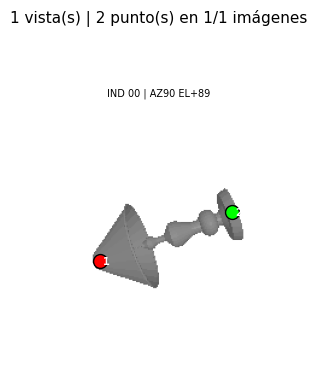


  Raw output:
  <points coords="1 1 279 576 2 768 394;2 3 279 576 4 768 394;3 5 279 576 6 768 394">


════════════════════════════════════════════════════════════
  EXPERIMENTO: 6 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png', 'IND_01_AZ_137_EL_+79_ROT_000.png', 'IND_02_AZ_276_EL_+74_ROT_000.png', 'IND_03_AZ_052_EL_+71_ROT_000.png', 'IND_04_AZ_190_EL_+68_ROT_000.png', 'IND_05_AZ_328_EL_+65_ROT_000.png']
  Ejecutando inferencia...
  Puntos detectados: 12
  → Guardado: outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment/exp_06_views.png


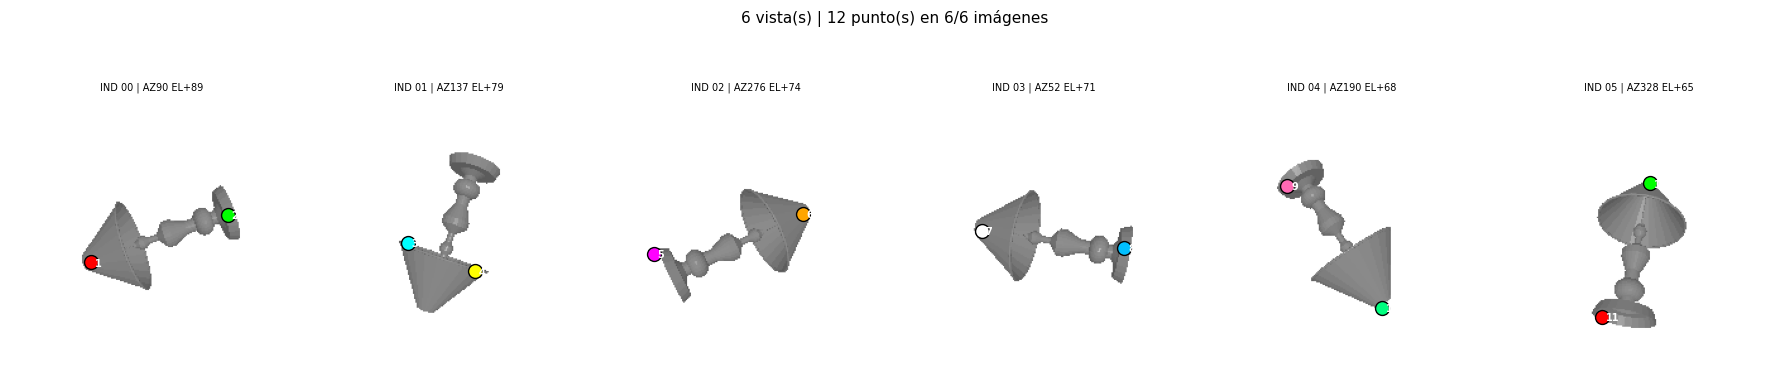


  Raw output:
  <points coords="1 1 286 578 2 768 409;2 3 352 510 4 591 610;3 5 171 547 6 698 406;4 7 279 467 8 783 527;5 9 307 306 10 643 739;6 11 368 772 12 538 298">


════════════════════════════════════════════════════════════
  EXPERIMENTO: 14 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png', 'IND_01_AZ_137_EL_+79_ROT_000.png', 'IND_02_AZ_276_EL_+74_ROT_000.png', 'IND_03_AZ_052_EL_+71_ROT_000.png', 'IND_04_AZ_190_EL_+68_ROT_000.png', 'IND_05_AZ_328_EL_+65_ROT_000.png', 'IND_06_AZ_105_EL_+63_ROT_000.png', 'IND_07_AZ_243_EL_+61_ROT_000.png', 'IND_08_AZ_020_EL_+59_ROT_000.png', 'IND_09_AZ_157_EL_+57_ROT_000.png', 'IND_10_AZ_296_EL_+55_ROT_000.png', 'IND_11_AZ_072_EL_+53_ROT_000.png', 'IND_12_AZ_211_EL_+51_ROT_000.png', 'IND_13_AZ_348_EL_+50_ROT_000.png']
  Ejecutando inferencia...
  Puntos detectados: 28
  → Guardado: outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment/exp_14_views.png


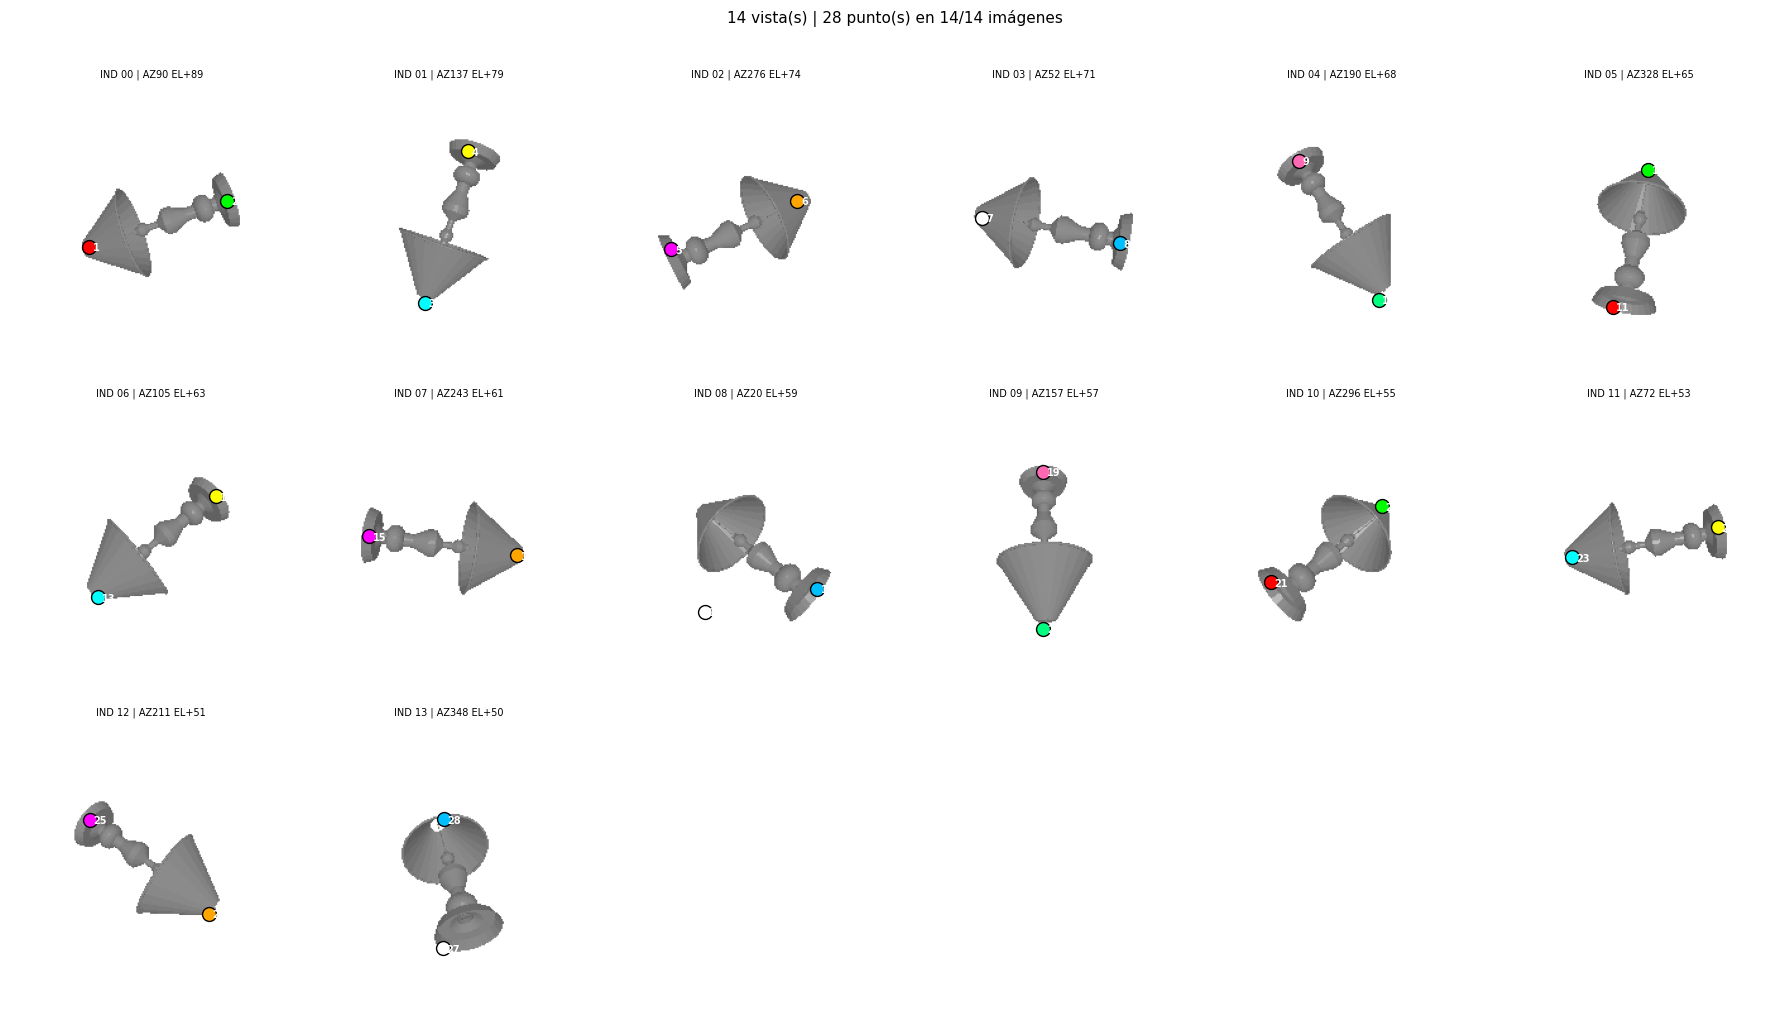


  Raw output:
  <points coords="1 1 279 569 2 766 406;2 3 412 767 4 566 231;3 5 232 578 6 679 406;4 7 280 467 8 766 556;5 9 348 264 10 630 756;6 11 405 781 12 532 297;7 13 309 681 14 727 322;8 15 216 464 16 741 531;9 17 352 731 18 748 650;10 19 495 236 20 495 792;11 21 248 628 22 641 358;12 23 262 539 24 777 433;13 25 280 339 26 702 672;14 27 477 794 28 480 336">points</points>


════════════════════════════════════════════════════════════
  EXPERIMENTO: 26 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png', 'IND_01_AZ_137_EL_+79_ROT_000.png', 'IND_02_AZ_276_EL_+74_ROT_000.png', 'IND_03_AZ_052_EL_+71_ROT_000.png', 'IND_04_AZ_190_EL_+68_ROT_000.png', 'IND_05_AZ_328_EL_+65_ROT_000.png', 'IND_06_AZ_105_EL_+63_ROT_000.png', 'IND_07_AZ_243_EL_+61_ROT_000.png', 'IND_08_AZ_020_EL_+59_ROT_000.png', 'IND_09_AZ_157_EL_+57_ROT_000.png', 'IND_10_AZ_296_EL_+55_ROT_000.png', 'IND_11_AZ_072_EL_+53_ROT_000.png', 'IND_12_AZ_21

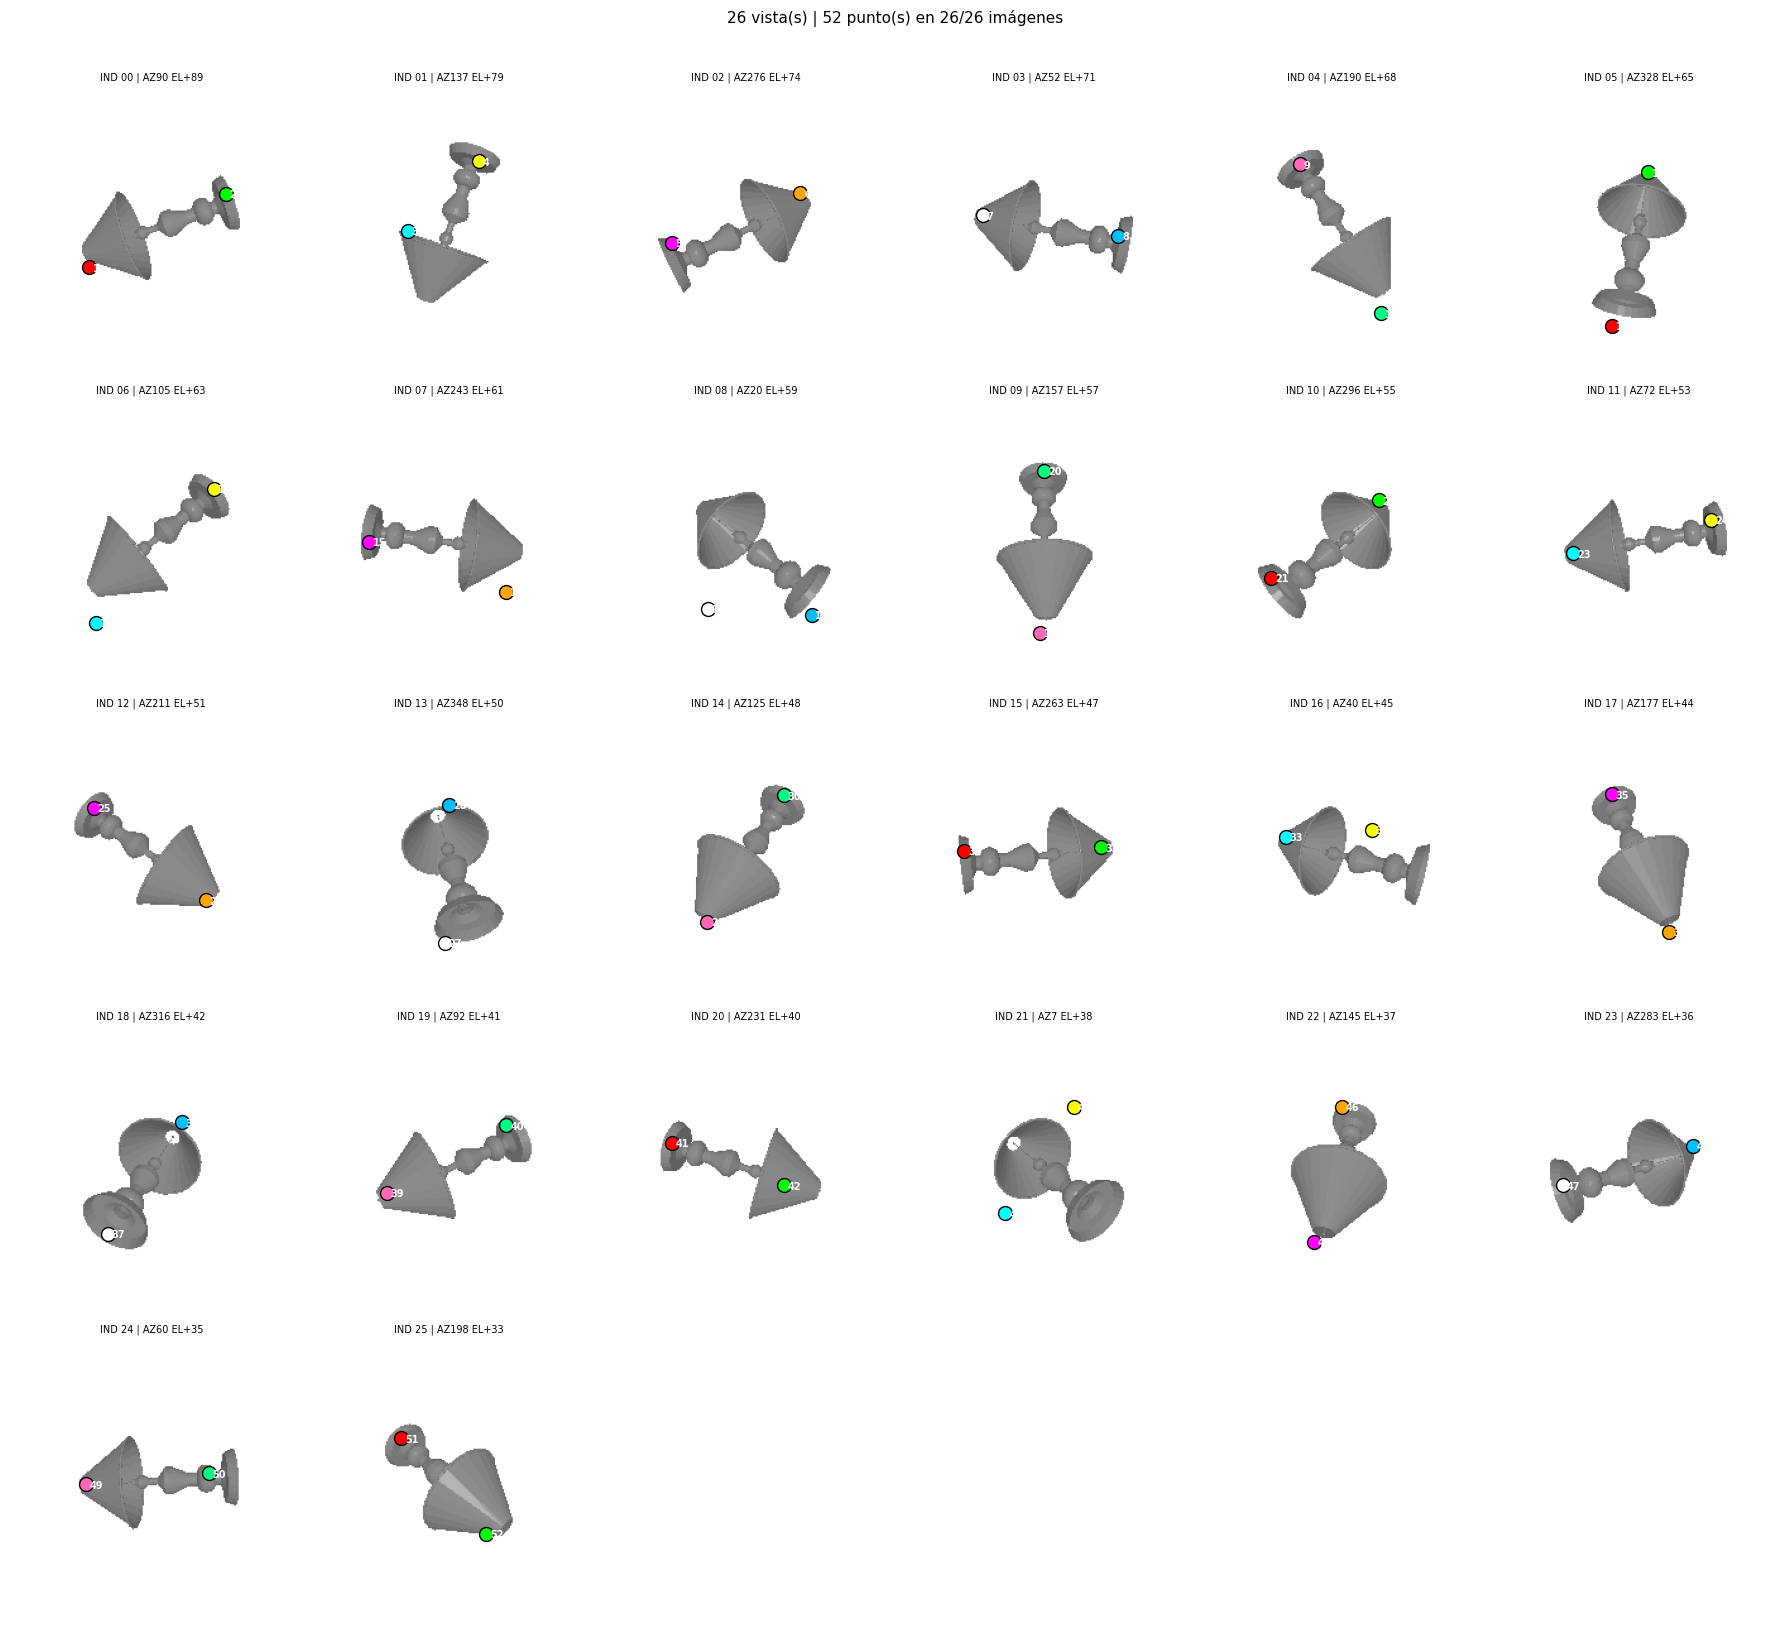


  Raw output:
  <tracks coords="1 1 279 631 2 762 370;2 3 352 502 4 606 256;3 5 234 544 6 689 369;4 7 282 447 8 762 519;5 9 352 267 10 640 794;6 11 402 838 12 530 294;7 13 302 781 14 719 306;8 15 216 494 16 702 672;9 17 362 731 18 729 752;10 19 484 817 20 500 244;11 21 249 622 22 630 347;12 23 266 536 24 754 417;13 25 294 328 26 690 656;14 27 484 806 28 500 317;15 29 359 731 30 630 283;16 31 216 481 32 702 467;17 33 302 431 34 606 406;18 35 402 281 36 606 767;19 37 344 728 38 606 333;20 39 279 583 40 702 344;21 41 234 406 42 630 556;22 43 362 656 44 606 278;23 45 402 756 46 500 278;24 47 229 556 48 690 417;25 49 266 506 50 702 467;26 51 329 344 52 630 681">



In [ ]:
metadata = load_metadata(render_dir)
print(f"Total imágenes en metadata: {len(metadata)}")

all_results = {}  # guarda resultados por grupo

for n_views in EXPERIMENTS:
    print("\n" + "═" * 60)
    print(f"  EXPERIMENTO: {n_views} vista(s)")
    print("═" * 60)

    entries = get_rot000_entries(metadata, n_views)
    images  = load_images(entries, render_dir)

    print(f"  Imágenes cargadas: {[e['filename'] for e in entries]}")
    print("  Ejecutando inferencia...")

    #prompt = (
    #f"These are {len(images)} views of the same 3D object with one main axis of "
    #f"rotational symmetry. For each image, point to exactly 2 points only: "
    #f"1. where the axis exits the top of the object"
    #f"2. where the axis exits the bottom of the object."
    #f"Use the multi-image points format for both points:"
    #f"<points coords='1 1 X1 Y1 2 X2 Y2; 2 3 X1 Y1 4 X2 Y2; 3 5 X1 Y1 6 X2 Y2; 4 7 X1 Y1 8 X2 Y2; 5 9 X1 Y1 10 X2 Y2; 6 11 X1 Y1 12 X2 Y2'>"
    #f"Where the numbers before X,Y are: image_index obj_id X Y."
    #f"Replace X1,Y1 with the top point and X2,Y2 with the bottom point for each image."
    #)

    prompt_multiview = """
You are given multiple views of the SAME 3D object.

The object has ONE dominant axis of rotational symmetry.

Your task is to estimate the SAME global 3D symmetry axis across all views and project that axis into each image.

For each image:

1. Identify the visible projection of the global symmetry axis.
2. Return:
   - one point where the projected axis intersects the object near the TOP,
   - one point where the projected axis intersects the object near the BOTTOM.

IMPORTANT RULES:
- The 2 points of each image MUST be collinear.
- Use the SAME global axis consistently across all views.
- Do NOT place all points at the image center unless the axis projection is truly degenerate.
- Infer the axis from ALL views jointly before answering.
- Even if some views are ambiguous, maintain consistency with the other views.
- Only output points for the dominant rotational symmetry axis.

Output format:

<points coords="
1 1 Xtop Ytop 2 Xbottom Ybottom;
2 4 Xtop Ytop 5 Xbottom Ybottom;
3 7 Xtop Ytop 8 Xbottom Ybottom
">

Where each entry is:
image_index object_id X Y

Example:
Image 1:
- point 1 = TOP
- point 2 = BOTTOM

Image 2:
- point 4 = TOP
- point 5 = BOTTOM

Return ONLY the <points ...> block.

    """

    prompt_unique = """ 
    You are given ONE image of a 3D object.

The object has ONE dominant rotational symmetry axis.

Your task is to estimate the 2D projection of the object's main symmetry axis.

Return TWO distant points lying on the same projected symmetry axis line.

IMPORTANT RULES:
- The two points MUST be different.
- The two points MUST be as far apart as possible along the symmetry axis.
- The points MUST lie on the visible object.
- Use the object's silhouette and geometry to infer the axis.
- Prefer the longest visible symmetry direction through the object.
- Do NOT place both points at the image center.
- If the object is approximately vertical, the axis should also be approximately vertical.

Output ONLY:

<points coords="1 1 X1 Y1 2 X2 Y2">
"""

    prompt_global = """You are given one or more images of the SAME 3D object.

The object has ONE dominant rotational symmetry axis.

Your task is to estimate the projection of the object's main symmetry axis in EACH image.

For every image, return TWO points that lie on the projected symmetry axis.

IMPORTANT RULES:
- The two points of each image MUST be different.
- The two points MUST lie on the same symmetry axis line.
- The points should be as far apart as possible along the visible axis.
- The points MUST lie on the visible object region.
- Use the object's geometry and silhouette to infer the axis.
- When multiple images are provided, use all views jointly to maintain consistency across images.
- Even if some views are ambiguous, keep the predicted axis consistent with the other views.
- Do NOT collapse points to the image center unless the axis projection is truly degenerate.
- Do NOT repeat identical coordinates for different points unless strictly necessary.

Output format:

<points coords="
1 1 X1 Y1 2 X2 Y2;
2 3 X1 Y1 4 X2 Y2;
3 5 X1 Y1 6 X2 Y2
">

Where each entry is:
image_index object_id X Y

For each image:
- first point = endpoint 1 of the projected symmetry axis
- second point = endpoint 2 of the projected symmetry axis

Return ONLY the <points ...> block."""

    raw = run_inference(images, prompt=prompt_multiview)

    # Parsear según número de imágenes
    #if n_views == 1:
    #    # Imagen individual: formato RADIO ID X Y ...
    #    pts_single = parse_single_image_coords(raw)
    #    points_by_image = {0: pts_single} if pts_single else {}
    #else:
    #    # Multi-imagen: formato img_idx obj_id X Y ; ...
    points_by_image = parse_multiimage_coords(raw, n_images=n_views)

    n_pts = sum(len(v) for v in points_by_image.values())
    print(f"  Puntos detectados: {n_pts}")

    # Guardar resultado
    all_results[n_views] = {
        "raw_output":      raw,
        "points_by_image": {
            str(k): [{"obj_id": p[0], "x": p[1], "y": p[2]} for p in v]
            for k, v in points_by_image.items()
        },
        "entries": [
            {"filename": e["filename"], "index": e["index"],
             "azimuth": e["azimuth"], "elevation": e["elevation"]}
            for e in entries
        ],
        "n_points": n_pts,
        "n_images_with_points": len(points_by_image),
    }

    plot_group_results(
        images         = images,
        entries        = entries,
        points_by_image= points_by_image,
        n_views        = n_views,
        raw_output     = raw,
        save_path      = OUTPUT_DIR / f"exp_{n_views:02d}_views.png",
    )

## 4. Resumen comparativo

In [5]:
print(f"{'Vistas':<10} {'Imgs con puntos':<20} {'Total puntos':<15} {'¿Coords o texto?'}")
print("-" * 60)

for n_views, res in all_results.items():
    has_coords = "coords=" in res["raw_output"]
    fmt        = "coords" if has_coords else "texto descriptivo"
    print(
        f"{n_views:<10} "
        f"{res['n_images_with_points']}/{n_views:<17} "
        f"{res['n_points']:<15} "
        f"{fmt}"
    )

Vistas     Imgs con puntos      Total puntos    ¿Coords o texto?
------------------------------------------------------------
1          1/1                 1               coords
6          6/6                 18              coords
14         14/14                42              coords
26         26/26                26              coords


## 5. Guardar resultados

In [6]:
out_json = OUTPUT_DIR / "multiview_experiment_results.json"

# Serializar (entries ya son dicts, points_by_image tiene keys str)
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(
        {
            "object_id":     OBJECT_ID,
            "symmetry_type": SYMMETRY_TYPE,
            "image_size":    IMAGE_SIZE,
            "illumination":  ILLUMINATION,
            "prompt":        PROMPT,
            "experiments":   all_results,
        },
        f, indent=2,
    )

print(f"Resultados guardados en: {out_json}")

NameError: name 'PROMPT' is not defined

---
## Notas sobre el formato de coordenadas

### Imagen individual
```
<points coords="RADIO  ID X Y  ID X Y ...">
```
El primer número es el radio (descartado). Luego tripletas `(ID, X, Y)`.

### Multi-imagen (paper §coordenadas, p.27)
```
<points coords="img_idx obj_id X Y  obj_id X Y ; img_idx obj_id X Y ...">
```
- `;` separa grupos por imagen
- `img_idx`: índice de imagen, **1-based**
- `obj_id`: ID del objeto dentro de la imagen, 1-based
- `X, Y`: coordenadas en escala **0–1000**, origen **superior-izquierda** (sin invertir Y en matplotlib)

### Conversión a píxeles
```python
px = x / 1000 * image_width
py = y / 1000 * image_height   # sin invertir Y
```